In [ ]:
import sys
sys.path.append('../src')

import scipy.io as sio
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from preprocessing import filter_all_channels
from features import extract_all_windows
from config import FS, N_CLASSES

# Load data
mat_data = sio.loadmat('../data/S17_E1_A1.mat')
emg_raw = mat_data['emg']
gesture_labels = mat_data['restimulus']

# Preprocess and extract features
emg_filtered = filter_all_channels(emg_raw)
feature_matrix, label_vector = extract_all_windows(emg_filtered, gesture_labels)

print(f"Dataset: {feature_matrix.shape[0]} windows, {feature_matrix.shape[1]} features, {len(np.unique(label_vector))} classes")

Dataset: 9022 windows, 48 features, 18 classes


In [ ]:
# Train and evaluate LDA
lda_classifier = LinearDiscriminantAnalysis()
cross_validator = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(lda_classifier, feature_matrix, label_vector,
                           cv=cross_validator, scoring='accuracy')

print(f"Cross-validation accuracy: {cv_scores.mean():.3f} ± {cv_scores.std():.3f}")
print(f"Per fold: {[f'{s:.3f}' for s in cv_scores]}")

Cross-validation accuracy: 0.649 ± 0.014
Per fold: ['0.627', '0.640', '0.652', '0.658', '0.669']


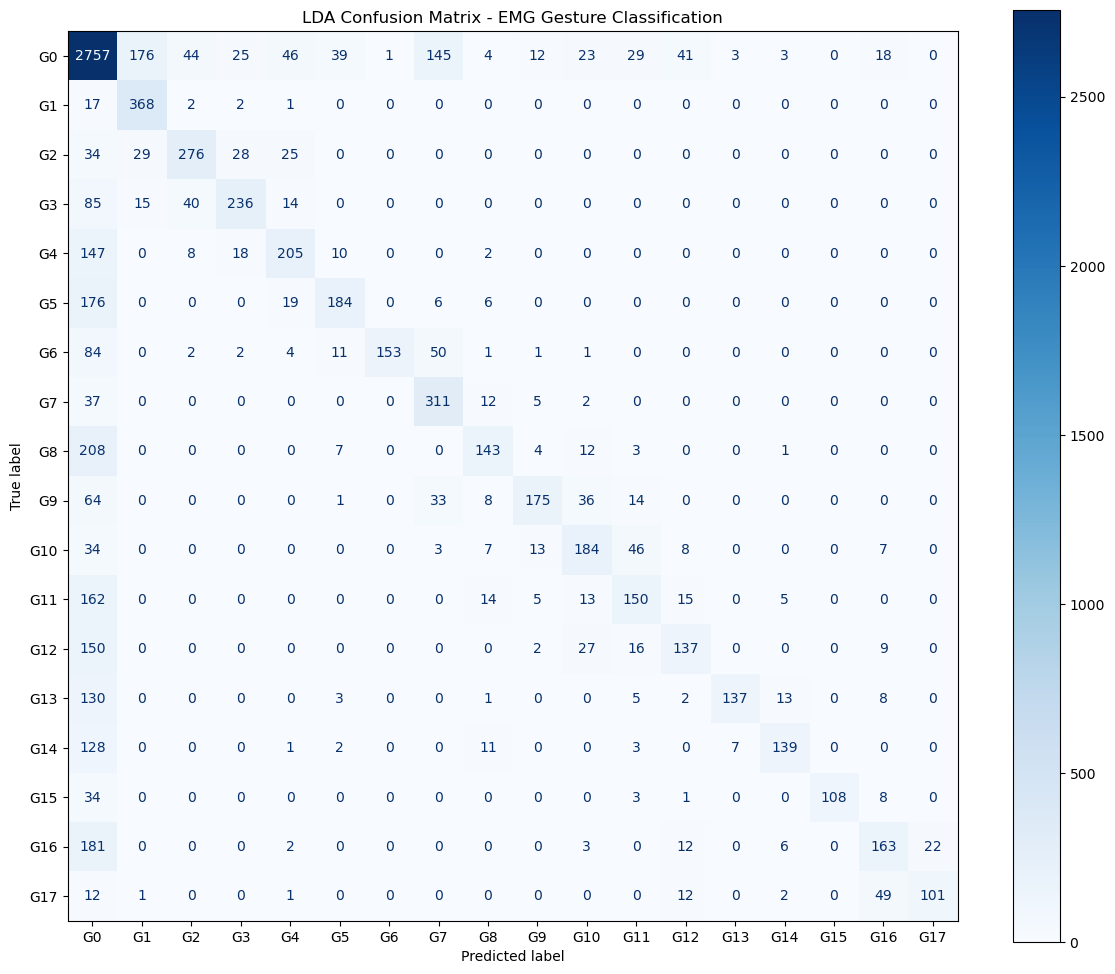

In [ ]:
# Fit on full data for confusion matrix
lda_classifier.fit(feature_matrix, label_vector)
predicted_labels = lda_classifier.predict(feature_matrix)

confusion_mat = confusion_matrix(label_vector, predicted_labels)
display_labels = [f'G{i}' for i in range(N_CLASSES)]
confusion_display = ConfusionMatrixDisplay(confusion_matrix=confusion_mat,
                                          display_labels=display_labels)

fig, ax = plt.subplots(figsize=(12, 10))
confusion_display.plot(ax=ax, colorbar=True, cmap='Blues')
plt.title('LDA Confusion Matrix - EMG Gesture Classification')
plt.tight_layout()
plt.show()